# 02 — Analyse Exploratoire (EDA)

**Données** : BaseCLD2026 — Contamination des sols au chlordécone (Martinique)  
**Objectifs de ce notebook** :
- Comprendre la distribution des concentrations en chlordécone
- Identifier les facteurs liés à la contamination (sol, pluie, historique bananier)
- Visualiser les tendances temporelles et géographiques
- Préparer les features pour la modélisation

> 💡 **Rappel** : Ce notebook part du fichier `BaseCLD2026_clean.csv` produit par le notebook 01.

---
## 0. Imports & chargement des données

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

# Style global des graphiques
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# Chargement du fichier nettoyé (produit par notebook 01)
df=pd.read_csv("C:/Users/Utilisateur/Downloads/chlordecone-project/data/processed/BaseCLD2026_clean.csv")
# Seuil réglementaire pour les sols agricoles (mg/kg)
SEUIL = 0.1

# Variable cible binaire : 1 = contaminé au-dessus du seuil, 0 = en dessous
df['contamine'] = (df['Taux_Chlordecone_clean'] > SEUIL).astype(int)

print(f'Dataset chargé : {df.shape[0]:,} observations, {df.shape[1]} variables')
print(f'Taux de contamination (> {SEUIL} mg/kg) : {df["contamine"].mean()*100:.1f}%')
df.head(3)

Dataset chargé : 31,126 observations, 29 variables
Taux de contamination (> 0.1 mg/kg) : 34.6%


,ID,ANNEE,COMMU_LAB,RAIN,Sol_simple,type_sol,Date_prelevement,Date_enregistrement,Date_analyse,Operateur_chld,...,mnt_pente_mean,X,Y,chl_censure,Taux_Chlordecone_clean,Taux_5b_hydro_clean,histoBanane_cat,log_chl,log_5b,contamine
0,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,39.043098,714300.831892,1.626344e+06,0,4.6,0.07,2,1.722767,0.067659,1
1,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,38.123675,714303.743345,1.626354e+06,0,4.6,0.07,2,1.722767,0.067659,1
2,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,34.976678,714309.446765,1.626360e+06,0,4.6,0.07,3,1.722767,0.067659,1



## 1. Statistiques descriptives

### 1.1 Résumé statistique des variables numériques

In [7]:
# Variables numériques d'intérêt
num_cols = [
    'Taux_Chlordecone_clean', 'Taux_5b_hydro_clean',
    'mnt_pente_mean', 'mnt_tpi_mean', 'mnt_tri_mean',
    'mnt_rugosite_mean', 'mnt_ombrage_mean', 'mnt_exposition_mean'
]

desc = df[num_cols].describe().T

# Ajout de statistiques supplémentaires utiles
desc['skewness'] = df[num_cols].skew().round(2)          # asymétrie
desc['cv_%']     = (desc['std'] / desc['mean'] * 100).round(1)  # coefficient de variation

desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,cv_%
Taux_Chlordecone_clean,31126.0,0.667,1.560,0.000,0.002,0.003,0.410,17.350,3.70,233.9
Taux_5b_hydro_clean,31126.0,324.210,238.380,0.001,0.040,499.500,499.500,499.500,-0.62,73.5
mnt_pente_mean,31126.0,20.265,13.368,0.000,10.805,17.902,27.083,124.950,1.61,66.0
mnt_tpi_mean,31126.0,0.212,2.578,-29.066,-0.875,0.120,1.264,26.012,-0.42,1217.7
mnt_tri_mean,31126.0,4.313,2.858,0.000,2.375,3.822,5.625,29.358,2.07,66.3
mnt_rugosite_mean,31126.0,13.443,8.622,0.000,7.500,12.000,17.752,85.396,1.65,64.1
mnt_ombrage_mean,31126.0,175.030,27.881,24.789,159.431,177.103,193.249,255.000,-0.59,15.9
mnt_exposition_mean,31126.0,170.170,95.695,0.000,89.800,169.309,249.215,359.145,0.08,56.2


 📌 **À lire** : La `skewness` (asymétrie) très élevée du taux de chlordécone confirme que la distribution est très étalée vers les hautes valeurs → la transformation log est indispensable pour analyser cette variable.

### 1.2 Distribution du taux de chlordécone : brute vs log

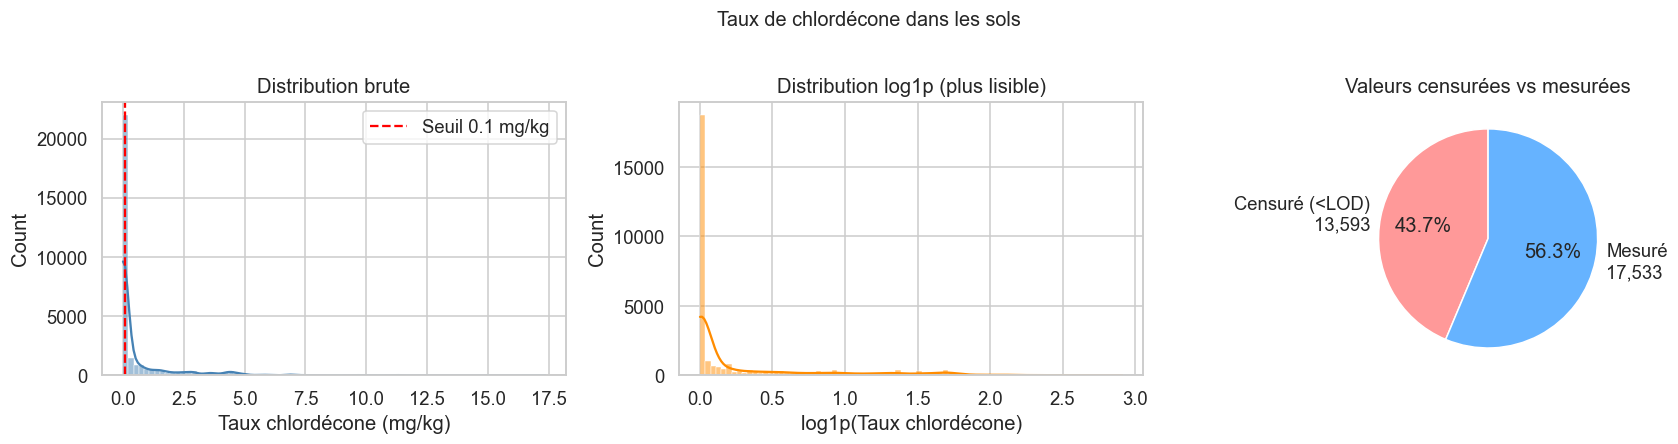

Médiane : 0.0032 mg/kg
Moyenne : 0.6670 mg/kg
95e percentile : 4.200 mg/kg
Maximum : 17.350 mg/kg


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Échelle brute 
sns.histplot(df['Taux_Chlordecone_clean'], bins=80, ax=axes[0],
             color='steelblue', kde=True)
axes[0].axvline(SEUIL, color='red', linestyle='--', label=f'Seuil {SEUIL} mg/kg')
axes[0].set_title('Distribution brute')
axes[0].set_xlabel('Taux chlordécone (mg/kg)')
axes[0].legend()

#  Échelle log 
# log1p(x) = log(1+x), pratique car gère les zéros
sns.histplot(df['log_chl'], bins=80, ax=axes[1], color='darkorange', kde=True)
axes[1].set_title('Distribution log1p (plus lisible)')
axes[1].set_xlabel('log1p(Taux chlordécone)')

#  Part de valeurs censurées 
nb_censure  = (df['chl_censure'] == 1).sum()
nb_mesure   = (df['chl_censure'] == 0).sum()
axes[2].pie([nb_censure, nb_mesure],
            labels=[f'Censuré (<LOD)\n{nb_censure:,}', f'Mesuré\n{nb_mesure:,}'],
            autopct='%1.1f%%',
            colors=['#ff9999', '#66b3ff'],
            startangle=90)
axes[2].set_title('Valeurs censurées vs mesurées')

plt.suptitle('Taux de chlordécone dans les sols', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Chiffres clés
print(f"Médiane : {df['Taux_Chlordecone_clean'].median():.4f} mg/kg")
print(f"Moyenne : {df['Taux_Chlordecone_clean'].mean():.4f} mg/kg")
print(f"95e percentile : {df['Taux_Chlordecone_clean'].quantile(0.95):.3f} mg/kg")
print(f"Maximum : {df['Taux_Chlordecone_clean'].max():.3f} mg/kg")

La distribution brute de CHLORDECONE_RATE est  asymétrique : la grande majorité des parcelles affichent des concentrations très faibles, mais une queue longue vers la droite révèle des niveaux parfois extrêmes. Après transformation log1p, la distribution devient symétrique et modélisable. Le troisième sous-graphe distingue les valeurs censurées (mesures sous le seuil de détection du laboratoire, notées < LOD) des valeurs réellement quantifiées.

43% des observations sont censurées, le laboratoire a détecté la présence de chlordécone mais n'a pas pu la quantifier précisément. Ce chiffre est lui-même révélateur : le chlordécone est présent partout, y compris là où on ne sait pas encore exactement à quelle dose. La transformation logarithmique est indispensable pour ne pas que les quelques valeurs extrêmes (zones de plantation intense) écrasent toute l'analyse.

### 1.3 Taux de contamination par type de sol, pluviométrie et historique bananier

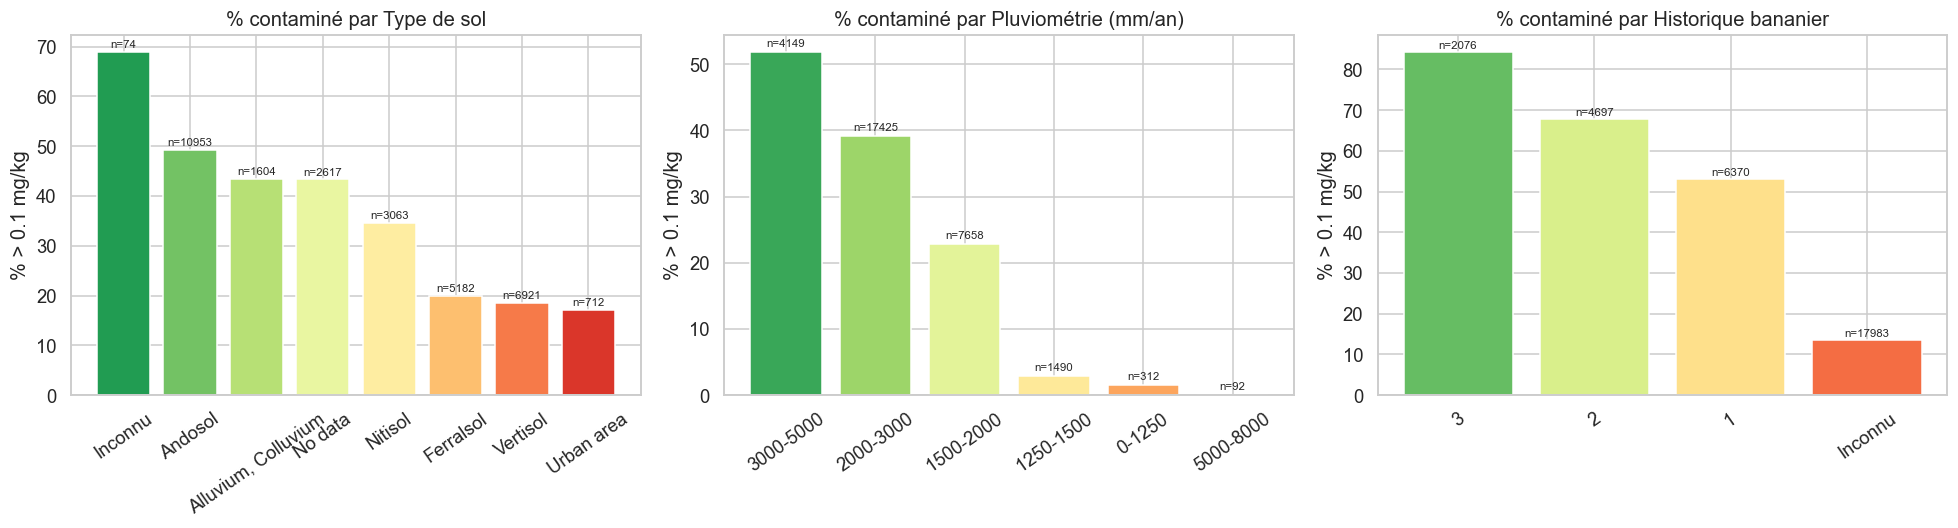

In [9]:
# Variables catégorielles à explorer
cat_vars   = ['Sol_simple', 'RAIN', 'histoBanane_cat']
cat_titles = ['Type de sol', 'Pluviométrie (mm/an)', 'Historique bananier']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var, title in zip(axes, cat_vars, cat_titles):
    # Calcul du % contaminé par groupe
    group = (
        df.groupby(var)['contamine']
          .agg(['mean', 'count'])
          .rename(columns={'mean': 'pct', 'count': 'n'})
          .sort_values('pct', ascending=False)
    )

    colors = sns.color_palette('RdYlGn_r', len(group))
    bars = ax.bar(group.index.astype(str), group['pct'] * 100, color=colors)

    # Afficher le nombre d'observations au-dessus de chaque barre
    for bar, (_, row) in zip(bars, group.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'n={int(row["n"])}',
                ha='center', fontsize=7.5)

    ax.set_title(f'% contaminé par {title}')
    ax.set_ylabel(f'% > {SEUIL} mg/kg')
    ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

Trois facteurs structurent la contamination. Les Andosols (sols volcaniques poreux typiques des hauteurs martiniquaises) retiennent davantage le chlordécone, leur structure chimique particulière fixe la molécule durablement. Les zones à pluviométrie intermédiaire (1250–3000 mm/an) sont plus touchées, probablement parce qu'elles correspondent aux zones de cultures bananières historiques. Enfin, plus l'occupation bananière a été longue (variable HISTOBANANE_HISTO_BAN : 0, 1, 2 ou 3 périodes entre 1970 et 1992), plus la contamination est élevée, première démonstration d'une relation dose-réponse qui sera le fil rouge de tout le projet.

### 1.4 Boxplots : distribution de la chlordecone( log_chl )   par type de sol

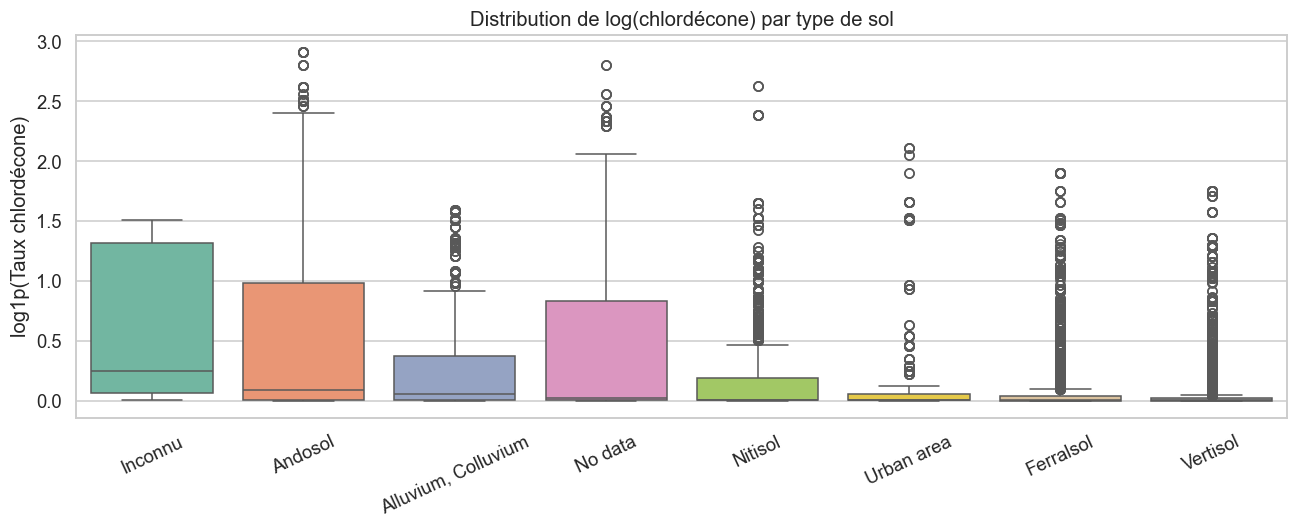

Test de Kruskal-Wallis : H = 4594.65, p = 0.00e+00
→ Les types de sol ont des niveaux de contamination significativement différents.


In [10]:
# Trier les types de sol par médiane décroissante
order = (
    df.groupby('Sol_simple')['log_chl']
      .median()
      .sort_values(ascending=False)
      .index
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='Sol_simple', y='log_chl',
            order=order, palette='Set2', ax=ax)

ax.set_title('Distribution de log(chlordécone) par type de sol')
ax.set_xlabel('')
ax.set_ylabel('log1p(Taux chlordécone)')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

# Test de Kruskal-Wallis : les groupes sont-ils significativement différents ?
# (test non-paramétrique, adapté aux distributions asymétriques)
groups = [grp['log_chl'].values for _, grp in df.groupby('Sol_simple')]
H, p = kruskal(*groups)
print(f'Test de Kruskal-Wallis : H = {H:.2f}, p = {p:.2e}')
if p < 0.05:
    print('→ Les types de sol ont des niveaux de contamination significativement différents.')
else:
    print('→ Pas de différence significative entre les types de sol.')

Les Andosols affichent une médiane et une dispersion vers le haut nettement supérieures aux Vertisols, Ferralsols et Nitisols.
La géologie n'est pas une fatalité, c'est une caractéristique structurelle du territoire qui amplifie ou atténue la pollution selon l'endroit. Un agriculteur cultivant sur Andosol dans les hauteurs du nord de la Martinique n'avait pas les mêmes risques qu'un cultivateur côtier sur Vertisol, mais aucun des deux n'était informé de cette réalité au moment de l'épandage. La variabilité intra-groupe reste forte, ce qui indique que le sol seul ne suffit pas à expliquer la contamination.


---
## 2. Corrélations

On utilise la **corrélation de Spearman** (plutôt que Pearson) car nos distributions sont asymétriques.

### 2.1 Matrice de corrélation globale

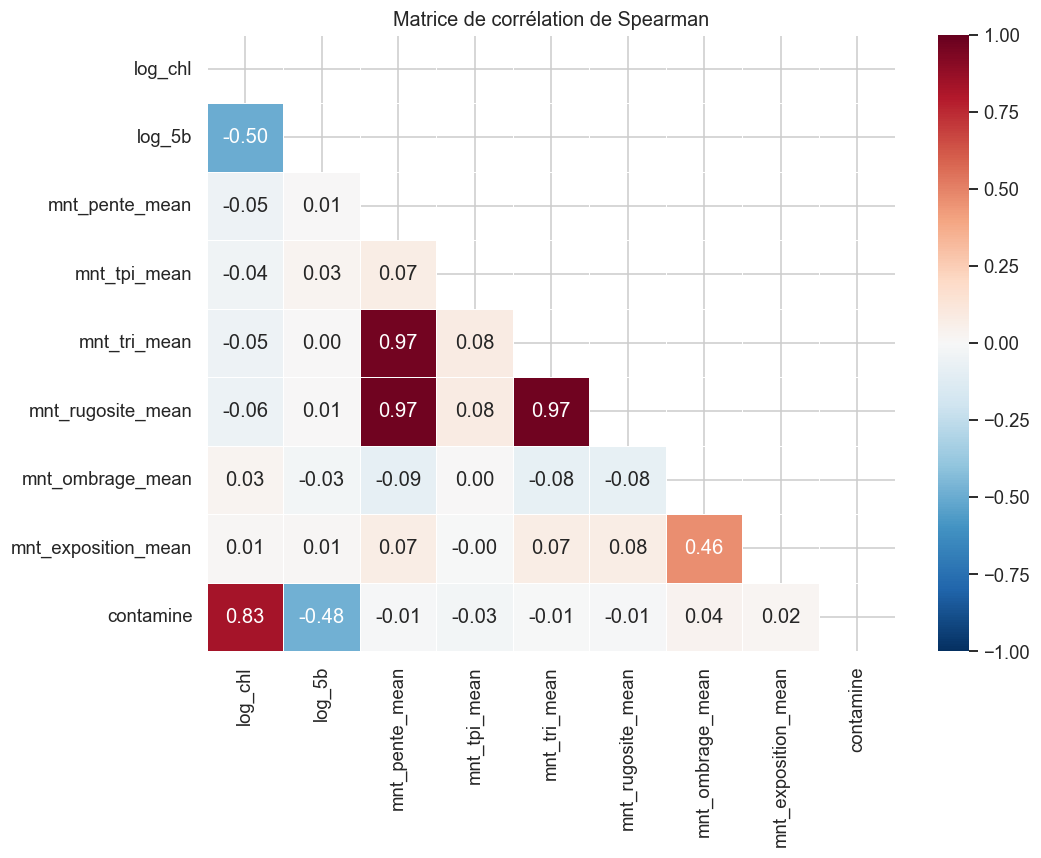

In [11]:
corr_cols = [
    'log_chl', 'log_5b',
    'mnt_pente_mean', 'mnt_tpi_mean', 'mnt_tri_mean',
    'mnt_rugosite_mean', 'mnt_ombrage_mean', 'mnt_exposition_mean',
    'contamine'
]

# Matrice de corrélation de Spearman
corr_matrix = df[corr_cols].corr(method='spearman')

# Masque pour n'afficher que le triangle inférieur (évite les doublons)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax
)
ax.set_title('Matrice de corrélation de Spearman', fontsize=13)
plt.tight_layout()
plt.show()

On choisit Spearman plutôt que Pearson parce que les distributions sont asymétriques. Pearson serait biaisé par les valeurs extrêmes. Les variables topographiques sont fortement corrélées entre elles (pente, TRI, rugosité mesurent des choses proches), ce qui créera de la multicolinéarité dans les modèles linéaires. 

Contamine, très corrélée positiviment (demontrer en haut) à HISTOBANANE_HISTO_BAN est la variable la plus corrélée avec log_chl, ce résultat posera la question politique centrale : si le lien entre banane et chlordécone était visible dans les données dès le départ, pourquoi l'épandage a-t-il continué ?

### 2.2 Chlordécone vs 5b-hydroxychlordécone

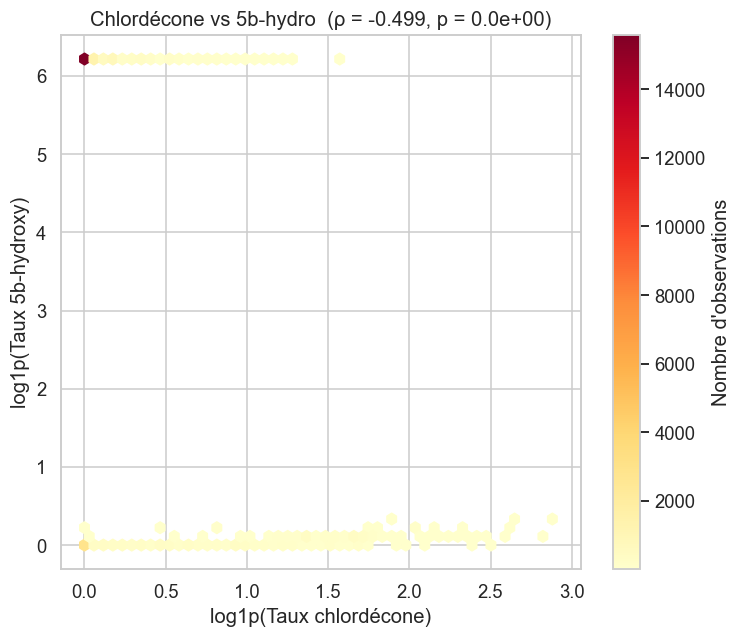

Corrélation de Spearman : ρ = -0.499
→ Les deux molécules sont fortement corrélées : les sols riches en chlordécone le sont aussi en 5b-hydro.


In [ ]:
rho, pval = spearmanr(df['log_chl'], df['log_5b'])

fig, ax = plt.subplots(figsize=(7, 6))

# hexbin : Parcequ'il y a beaucoup de points
hb = ax.hexbin(df['log_chl'], df['log_5b'],
               gridsize=50, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=ax, label="Nombre d'observations")

ax.set_xlabel('log1p(Taux chlordécone)')
ax.set_ylabel('log1p(Taux 5b-hydroxy)')
ax.set_title(f'Chlordécone vs 5b-hydro  (ρ = {rho:.3f}, p = {pval:.1e})')
plt.tight_layout()
plt.show()

print(f'Corrélation de Spearman : ρ = {rho:.3f}')
print('→ Les deux molécules sont fortement corrélées : les sols riches en chlordécone le sont aussi en 5b-hydro.')

La 5b-hydroxychlordécone est un produit de transformation chimique du chlordécone dans les sols. Leur forte corrélation spatiale indique que là où le chlordécone est présent en grande quantité, sa dégradation est aussi plus avancée mais cette dégradation est extrêmement lente. Ce graphique valide également la qualité des mesures : les deux molécules sont bien co-localisées, ce qui est le comportement attendu selon la chimie environnementale.

### 2.3 Corrélation topographie ↔ contamination

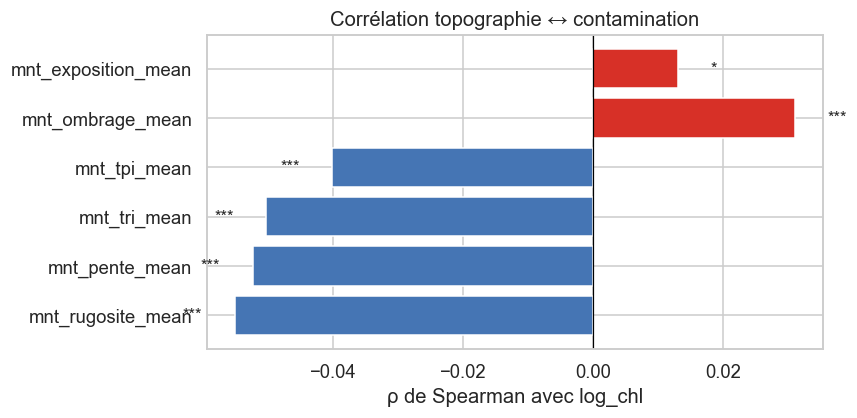

           variable       rho sig
  mnt_rugosite_mean -0.055148 ***
     mnt_pente_mean -0.052403 ***
       mnt_tri_mean -0.050362 ***
       mnt_tpi_mean -0.040180 ***
   mnt_ombrage_mean  0.031047 ***
mnt_exposition_mean  0.013051   *


In [13]:
topo_vars = [
    'mnt_pente_mean', 'mnt_tpi_mean', 'mnt_tri_mean',
    'mnt_rugosite_mean', 'mnt_ombrage_mean', 'mnt_exposition_mean'
]

# Calcul des corrélations de Spearman avec log_chl pour chaque variable topo
results = []
for var in topo_vars:
    rho, p = spearmanr(df['log_chl'], df[var])
    results.append({'variable': var, 'rho': rho, 'pval': p})

topo_corr = pd.DataFrame(results).sort_values('rho', key=abs, ascending=False)

# Étoiles de significativité
def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

topo_corr['sig'] = topo_corr['pval'].apply(sig_stars)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d73027' if r > 0 else '#4575b4' for r in topo_corr['rho']]
bars = ax.barh(topo_corr['variable'], topo_corr['rho'], color=colors)

for bar, sig in zip(bars, topo_corr['sig']):
    x = bar.get_width()
    offset = 0.005 if x >= 0 else -0.005
    ha = 'left' if x >= 0 else 'right'
    ax.text(x + offset, bar.get_y() + bar.get_height()/2,
            sig, va='center', ha=ha, fontsize=11)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('ρ de Spearman avec log_chl')
ax.set_title('Corrélation topographie ↔ contamination')
plt.tight_layout()
plt.show()

print(topo_corr[['variable', 'rho', 'sig']].to_string(index=False))

Le TPI (Topographic Position Index/ MNT_TPI_MEAN) mesure si une parcelle est en position de crête ou en fond de vallée. Son effet négatif sur la contamination signifie que les fonds de vallée accumulent davantage le chlordécone : l'eau de ruissellement transporte la molécule vers le bas des versants, où elle se concentre. En termes sanitaires, ce sont souvent ces zones basses qui alimentent les rivières et les captages d'eau. La pente (MNT_Pente_MEAN) joue un rôle similaire. La topographie n'est pas contrôlable, elle désigne objectivement les zones à surveiller en priorité.

### 2.4 Historique bananier ↔ contamination

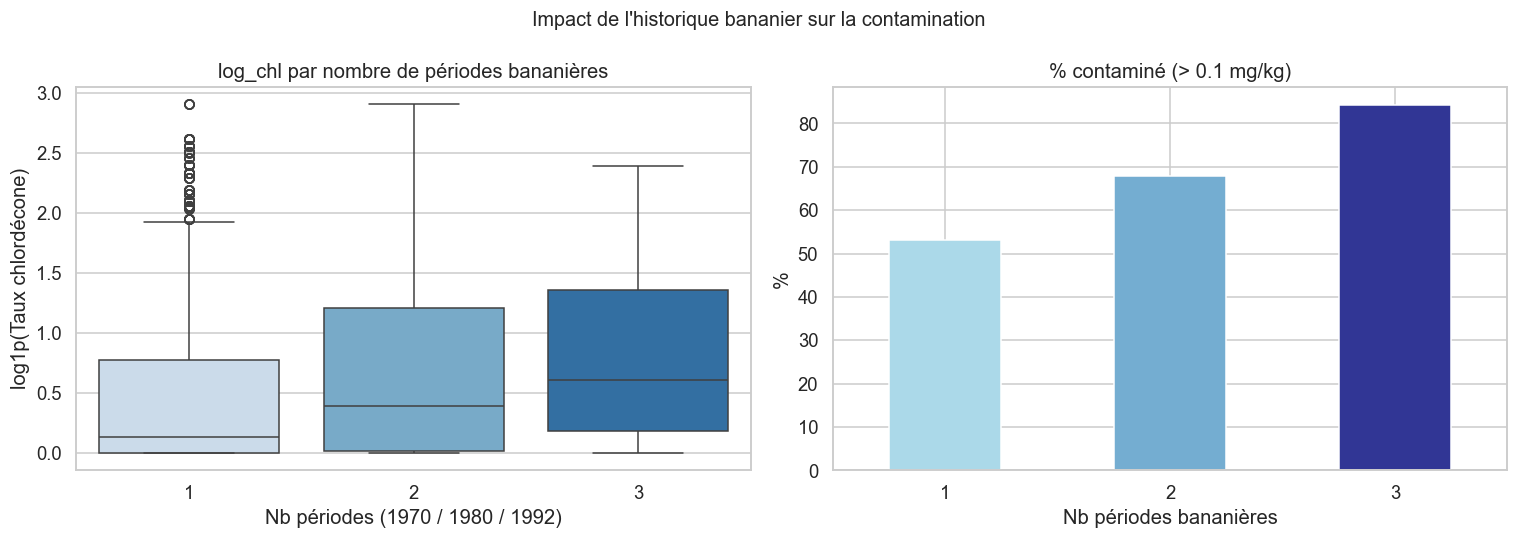

Kruskal-Wallis : H = 707.14, p = 2.80e-154

Test post-hoc de Tukey (comparaisons deux à deux) :
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     1      2   0.1955   0.0 0.1666 0.2244   True
     1      3   0.3308   0.0 0.2929 0.3688   True
     2      3   0.1353   0.0 0.0957 0.1749   True
-------------------------------------------------


In [14]:
# On exclut la catégorie Inconnu pour cette analyse
df_ban = df[df['histoBanane_cat'].isin(['1', '2', '3'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot log_chl par nombre de périodes bananières
sns.boxplot(data=df_ban, x='histoBanane_cat', y='log_chl',
            palette='Blues', order=['1', '2', '3'], ax=axes[0])
axes[0].set_title('log_chl par nombre de périodes bananières')
axes[0].set_xlabel('Nb périodes (1970 / 1980 / 1992)')
axes[0].set_ylabel('log1p(Taux chlordécone)')

# % contaminé par catégorie
pct = df_ban.groupby('histoBanane_cat')['contamine'].mean() * 100
pct.reindex(['1', '2', '3']).plot(kind='bar', ax=axes[1],
                                   color=['#abd9e9', '#74add1', '#313695'], rot=0)
axes[1].set_title(f'% contaminé (> {SEUIL} mg/kg)')
axes[1].set_ylabel('%')
axes[1].set_xlabel('Nb périodes bananières')

plt.suptitle('Impact de l\'historique bananier sur la contamination', fontsize=13)
plt.tight_layout()
plt.show()

# Test statistique : Kruskal-Wallis
g1 = df_ban[df_ban['histoBanane_cat']=='1']['log_chl']
g2 = df_ban[df_ban['histoBanane_cat']=='2']['log_chl']
g3 = df_ban[df_ban['histoBanane_cat']=='3']['log_chl']
H, p = kruskal(g1, g2, g3)
print(f'Kruskal-Wallis : H = {H:.2f}, p = {p:.2e}')

# Test post-hoc de Tukey (comparaisons deux à deux)
tukey = pairwise_tukeyhsd(df_ban['log_chl'], df_ban['histoBanane_cat'], alpha=0.05)
print('\nTest post-hoc de Tukey (comparaisons deux à deux) :')
print(tukey)

> 📌 **Interprétation** : Le test de Tukey confirme que chaque catégorie est significativement différente des autres (p < 0.05). On observe une **relation dose-réponse** : plus un sol a été occupé longtemps par des bananeraies, plus il est contaminé.

C'est le graphique le plus politiquement chargé de l'analyse. La relation est monotone, régulière et statistiquement certaine : chaque période supplémentaire de culture bananière entre 1970 et 1992 se traduit par un niveau de contamination significativement plus élevé, encore mesurable aujourd'hui. Or, des alertes scientifiques sur la toxicité du chlordécone existaient dès la fin des années 1960. Chaque année d'épandage supplémentaire après ces alertes a laissé une empreinte chimique mesurable dans les sols martiniquais et ce graphique en est la preuve quantifiée.

---
## 3. Analyse temporelle

### 3.1 Évolution annuelle de la contamination (2010–2019)

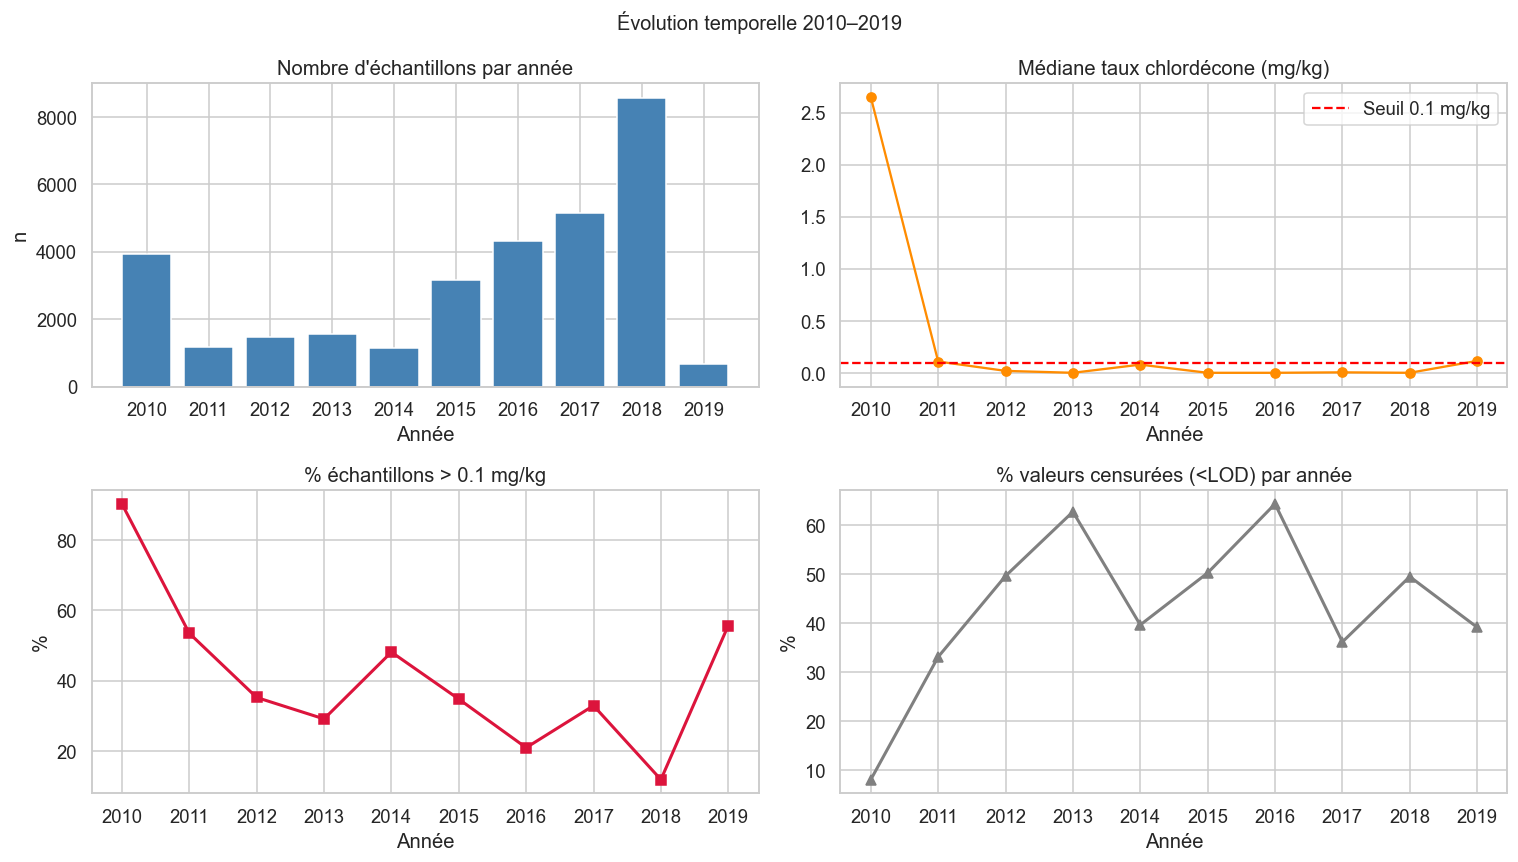

 ANNEE    n  mediane_chl  pct_contamine  pct_censure
  2010 3928      2.65000       0.902749     0.080448
  2011 1163      0.11000       0.534824     0.331040
  2012 1479      0.02000       0.352265     0.496281
  2013 1562      0.00165       0.291293     0.627401
  2014 1153      0.08000       0.481353     0.396357
  2015 3158      0.00165       0.347688     0.502533
  2016 4316      0.00165       0.209453     0.643420
  2017 5141      0.00600       0.329119     0.361603
  2018 8567      0.00165       0.118711     0.494922
  2019  659      0.11600       0.556904     0.391502


In [15]:
# Agrégation par année
yearly = (
    df.groupby('ANNEE')
      .agg(
          n                = ('Taux_Chlordecone_clean', 'count'),
          mediane_chl      = ('Taux_Chlordecone_clean', 'median'),
          pct_contamine    = ('contamine', 'mean'),
          pct_censure      = ('chl_censure', 'mean')
      )
      .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Nombre d'échantillons
axes[0, 0].bar(yearly['ANNEE'], yearly['n'], color='steelblue')
axes[0, 0].set_title("Nombre d'échantillons par année")
axes[0, 0].set_ylabel('n')

# Médiane du taux de chlordécone
axes[0, 1].plot(yearly['ANNEE'], yearly['mediane_chl'], marker='o', color='darkorange')
axes[0, 1].axhline(SEUIL, color='red', linestyle='--', label=f'Seuil {SEUIL} mg/kg')
axes[0, 1].set_title('Médiane taux chlordécone (mg/kg)')
axes[0, 1].legend()

# % contaminé
axes[1, 0].plot(yearly['ANNEE'], yearly['pct_contamine'] * 100,
                marker='s', color='crimson', linewidth=2)
axes[1, 0].set_title(f'% échantillons > {SEUIL} mg/kg')
axes[1, 0].set_ylabel('%')

# % censuré
axes[1, 1].plot(yearly['ANNEE'], yearly['pct_censure'] * 100,
                marker='^', color='grey', linewidth=2)
axes[1, 1].set_title('% valeurs censurées (<LOD) par année')
axes[1, 1].set_ylabel('%')

for ax in axes.flat:
    ax.set_xlabel('Année')
    ax.set_xticks(yearly['ANNEE'])

plt.suptitle('Évolution temporelle 2010–2019', fontsize=13)
plt.tight_layout()
plt.show()

print(yearly.to_string(index=False))

Le nombre d'échantillons (YEAR × effectifs) varie fortement, les campagnes de surveillance ne sont pas régulières ni homogènes dans le temps. Les fluctuations du taux de contamination apparent peuvent donc refléter des biais d'échantillonnage (certaines années, on a testé davantage de zones suspectées) plutôt qu'une vraie amélioration. Le chlordécone ayant une demi-vie de plusieurs décennies dans les sols, une baisse des mesures ne signifie pas une décontamination, elle peut signifier un changement de stratégie de prélèvement. Ces graphiques invitent à la prudence dans l'interprétation des tendances.

### 3.2 Délai entre prélèvement et analyse (qualité des données)

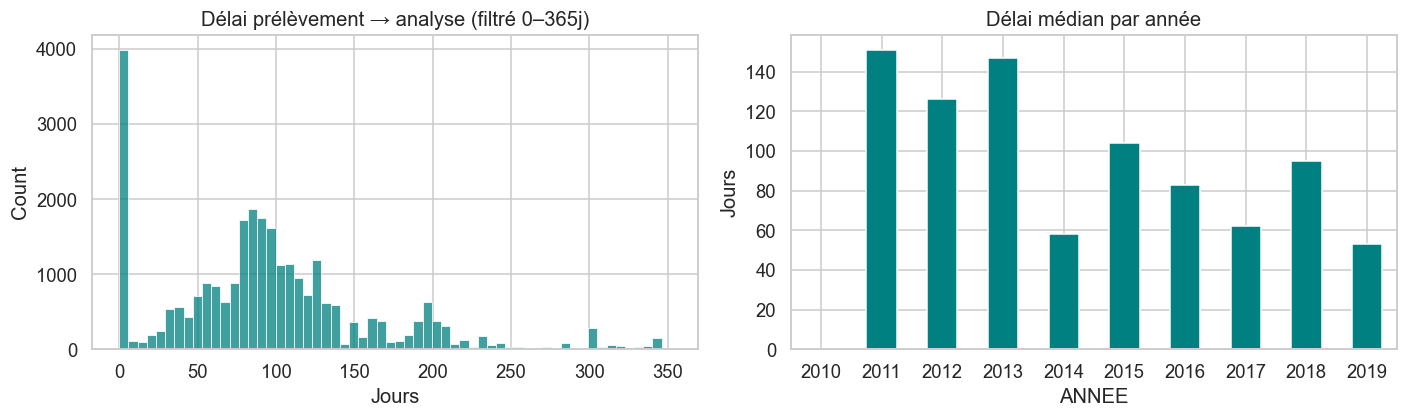

Délai médian global : 89 jours
Anomalies (délai négatif) : 89 observations


In [16]:
# Calcul du délai en jours
df['Date_prelevement'] = pd.to_datetime(df['Date_prelevement'], errors='coerce')
df['Date_analyse']     = pd.to_datetime(df['Date_analyse'],     errors='coerce')
df['delai_jours']      = (df['Date_analyse'] - df['Date_prelevement']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution des délais (on filtre les délais absurdes : > 365j ou négatifs)
delai_ok = df['delai_jours'].dropna()
delai_ok = delai_ok[(delai_ok >= 0) & (delai_ok <= 365)]

sns.histplot(delai_ok, bins=60, ax=axes[0], color='teal')
axes[0].set_title('Délai prélèvement → analyse (filtré 0–365j)')
axes[0].set_xlabel('Jours')

# Délai médian par année
df.groupby('ANNEE')['delai_jours'].median().plot(
    kind='bar', ax=axes[1], color='teal', rot=0)
axes[1].set_title('Délai médian par année')
axes[1].set_ylabel('Jours')

plt.tight_layout()
plt.show()

n_anomalies = (df['delai_jours'] < 0).sum()
print(f'Délai médian global : {delai_ok.median():.0f} jours')
print(f'Anomalies (délai négatif) : {n_anomalies} observations')

Un graphique de contrôle qualité des données, souvent négligé mais très important. Des délais très longs entre prélèvement et analyse peuvent induire une dégradation des échantillons et fausser les mesures vers le bas, ce qui amplifie le problème des valeurs censurées. Si des années montrent des délais médians anormalement élevés, les données de ces années doivent être interprétées avec davantage de prudence.

---
## 4. Analyse géographique

### 4.1 Carte de la contamination (scatter X/Y)

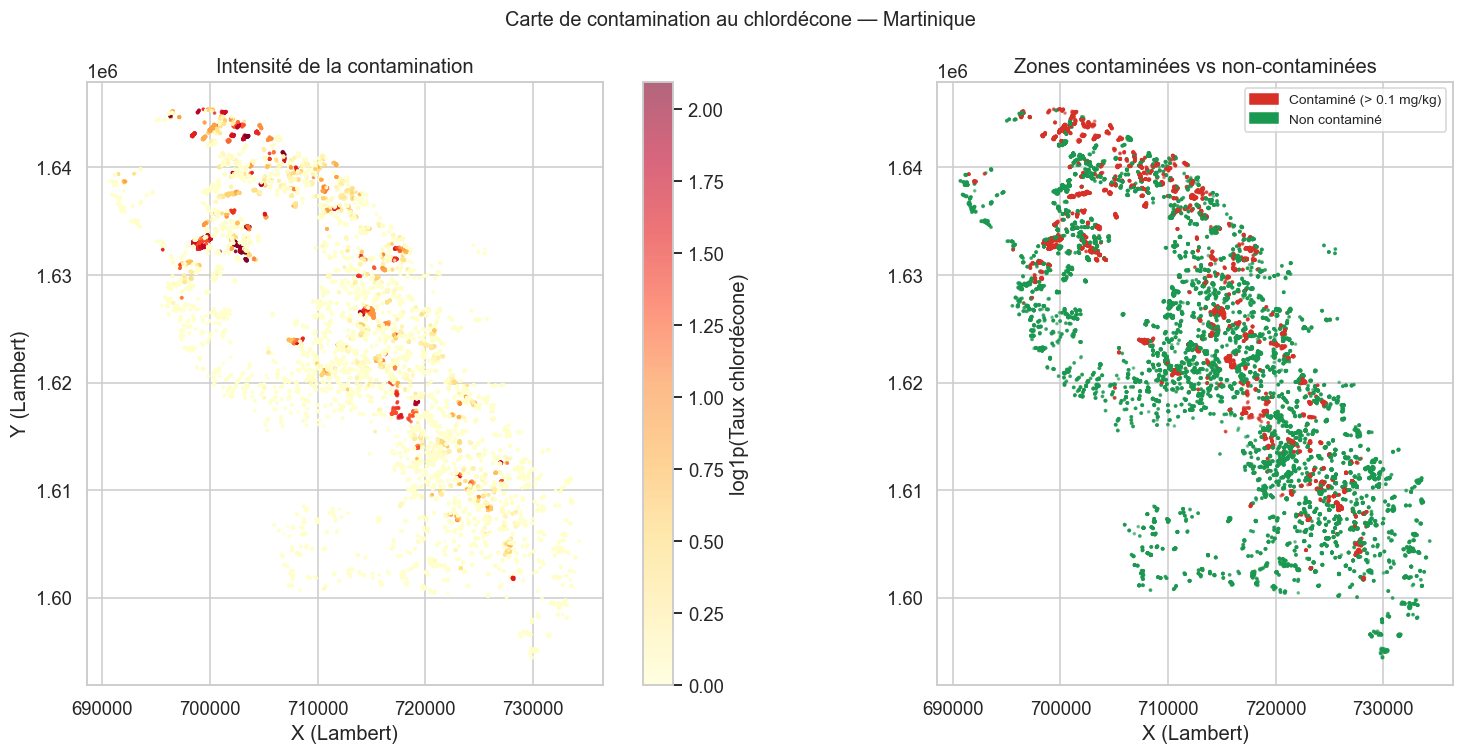

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Carte 1 : intensité de la contamination (log_chl)
sc1 = axes[0].scatter(
    df['X'], df['Y'],
    c=df['log_chl'], cmap='YlOrRd',
    s=2, alpha=0.6,
    vmin=0, vmax=df['log_chl'].quantile(0.99)  # on borne à 99e pct pour éviter l'écrasement
)
plt.colorbar(sc1, ax=axes[0], label='log1p(Taux chlordécone)')
axes[0].set_title('Intensité de la contamination')
axes[0].set_xlabel('X (Lambert)')
axes[0].set_ylabel('Y (Lambert)')
axes[0].set_aspect('equal')

# Carte 2 : contaminé (rouge) vs non-contaminé (vert)
from matplotlib.patches import Patch
colors_map = df['contamine'].map({1: '#d73027', 0: '#1a9850'})
axes[1].scatter(df['X'], df['Y'], c=colors_map, s=2, alpha=0.5)
axes[1].legend(
    handles=[
        Patch(color='#d73027', label=f'Contaminé (> {SEUIL} mg/kg)'),
        Patch(color='#1a9850', label='Non contaminé')
    ],
    loc='upper right', fontsize=9
)
axes[1].set_title('Zones contaminées vs non-contaminées')
axes[1].set_xlabel('X (Lambert)')
axes[1].set_aspect('equal')

plt.suptitle('Carte de contamination au chlordécone — Martinique', fontsize=13)
plt.tight_layout()
plt.show()

La contamination dessine une géographie précise de la Martinique, elle n'est pas aléatoire. Elle suit les zones historiques de plantation bananière intensive, principalement dans le centre et le nord de l'île. Cette empreinte spatiale est la signature visible et durable d'un demi-siècle d'agriculture productiviste. Pour les populations qui y vivent encore, ce graphique représente leur territoire quotidien contaminé pour plusieurs générations.

### 4.2 Top 15 communes les plus contaminées

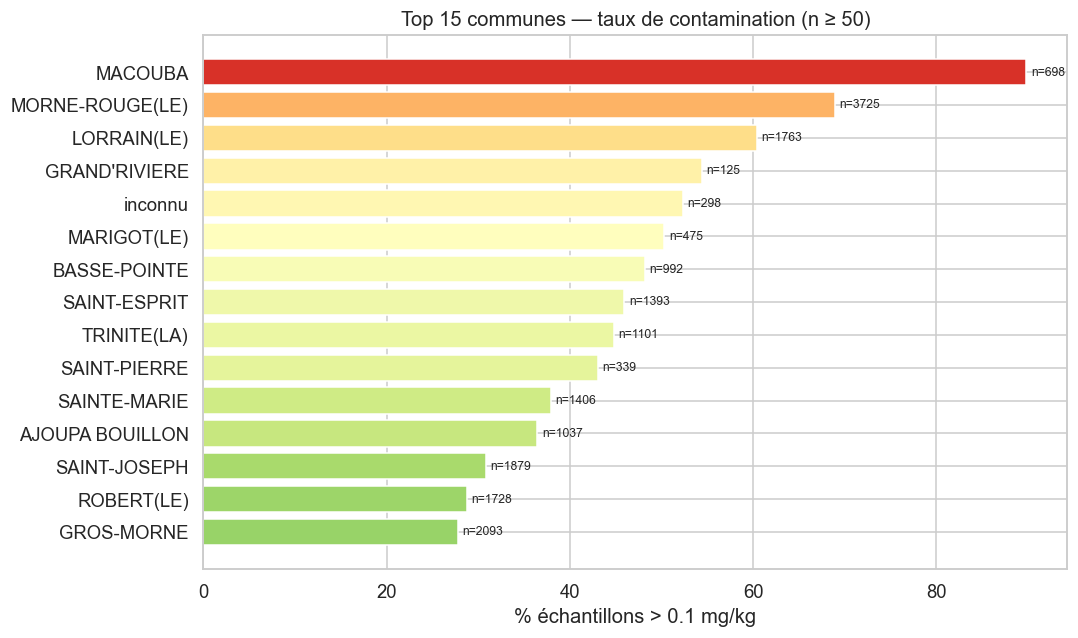

                    n  % contaminé
COMMU_LAB                         
MACOUBA           698         89.8
MORNE-ROUGE(LE)  3725         68.9
LORRAIN(LE)      1763         60.4
GRAND'RIVIERE     125         54.4
inconnu           298         52.3
MARIGOT(LE)       475         50.3
BASSE-POINTE      992         48.2
SAINT-ESPRIT     1393         45.9
TRINITE(LA)      1101         44.8
SAINT-PIERRE      339         43.1
SAINTE-MARIE     1406         37.9
AJOUPA BOUILLON  1037         36.5
SAINT-JOSEPH     1879         30.8
ROBERT(LE)       1728         28.8
GROS-MORNE       2093         27.8


In [18]:
# On filtre les communes avec au moins 50 observations pour avoir des résultats fiables
commu_stats = (
    df.groupby('COMMU_LAB')
      .agg(
          n             = ('log_chl', 'count'),
          mediane_chl   = ('log_chl', 'median'),
          pct_contamine = ('contamine', 'mean')
      )
      .query('n >= 50')
      .sort_values('pct_contamine', ascending=False)
      .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))

# Couleur proportionnelle au taux
colors = plt.cm.RdYlGn_r(commu_stats['pct_contamine'])
bars = ax.barh(commu_stats.index, commu_stats['pct_contamine'] * 100, color=colors)

for bar, (_, row) in zip(bars, commu_stats.iterrows()):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'n={int(row["n"])}', va='center', fontsize=8)

ax.invert_yaxis()
ax.set_xlabel(f'% échantillons > {SEUIL} mg/kg')
ax.set_title('Top 15 communes — taux de contamination (n ≥ 50)')
plt.tight_layout()
plt.show()

print(commu_stats[['n', 'pct_contamine']].assign(
    pct_contamine=lambda x: (x['pct_contamine']*100).round(1)
).rename(columns={'pct_contamine': '% contaminé'}).to_string())

Ce graphique est directement opérationnel pour les politiques publiques. Ces communes concentrent les situations les plus graves. Ce sont les zones où les restrictions sur l'usage des sols, la culture maraîchère ou l'élevage ont l'impact le plus fort sur la vie quotidienne et économique des habitants. 
Le seuil de n ≥ 50 est important : sans ce filtre, une commune avec 3 mesures toutes positives semblerait "100% contaminée" alors qu'elle n'a pas été suffisamment testée.


### 4.3 Évolution spatiale par période

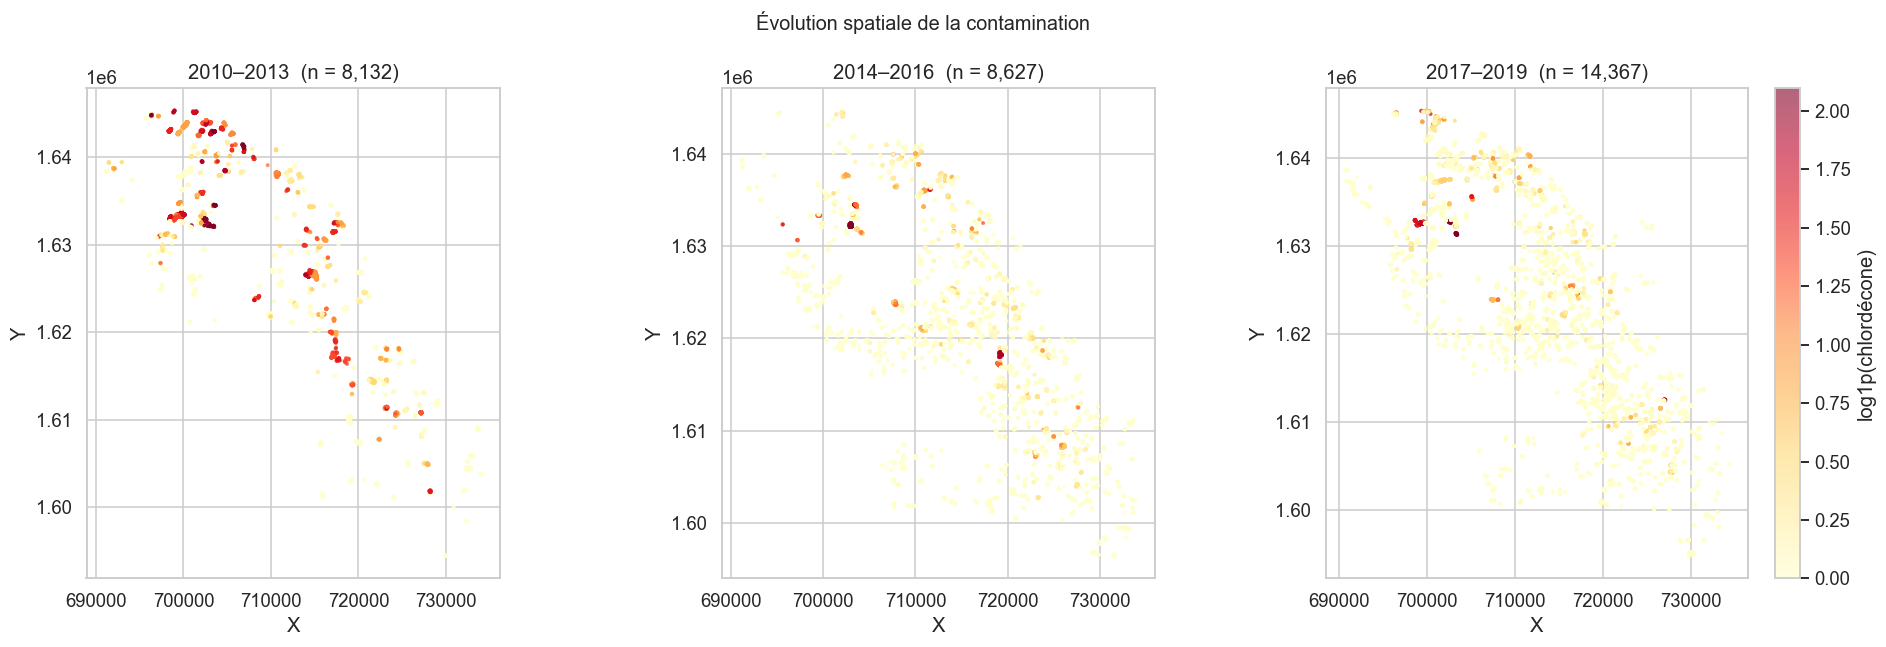

In [19]:
periodes = [(2010, 2013), (2014, 2016), (2017, 2019)]
labels   = ['2010–2013', '2014–2016', '2017–2019']
vmax     = df['log_chl'].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (y1, y2), label in zip(axes, periodes, labels):
    sub = df[(df['ANNEE'] >= y1) & (df['ANNEE'] <= y2)]
    sc  = ax.scatter(sub['X'], sub['Y'],
                     c=sub['log_chl'], cmap='YlOrRd',
                     s=3, alpha=0.6, vmin=0, vmax=vmax)
    ax.set_title(f'{label}  (n = {len(sub):,})')
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.colorbar(sc, ax=axes[-1], label='log1p(chlordécone)')
plt.suptitle('Évolution spatiale de la contamination', fontsize=13)
plt.tight_layout()
plt.show()

Les zones rouges restent aux mêmes endroits(centre et nord) d'une période à l'autre, confirmant que le chlordécone est immobile et persistant dans les sols sur des échelles de temps humaines. Ce n'est pas une pollution qui se résorbe naturellement à l'échelle d'une vie. Pour les agriculteurs et résidents de ces zones, ce graphique signifie concrètement : la contamination sera encore là à la retraite de leurs enfants.

---
## 5. Préparation des features pour la modélisation

Avant de passer au notebook 03 (modélisation), on prépare un dataset propre avec toutes les variables encodées.

### 5.1 Encodage des variables catégorielles

In [20]:
# Encodage ordinal de la pluviométrie (ordre logique croissant)
rain_order = {
    '0-1250': 0, '1250-1500': 1, '1500-2000': 2,
    '2000-3000': 3, '3000-5000': 4, '5000-8000': 5
}
df['rain_ord'] = df['RAIN'].map(rain_order)

# Encodage ordinal du type de sol
# (classé par capacité de rétention des pesticides approximative)
sol_order = {
    'Andosol': 4, 'Ferralsol': 3, 'Nitisol': 2,
    'Vertisol': 1, 'Alluvium, Colluvium': 1,
    'Urban area': 0, 'No data': -1, 'Inconnu': -1
}
df['sol_ord'] = df['Sol_simple'].map(sol_order).fillna(-1).astype(int)

# Encodage numérique de l'historique bananier
# ('Inconnu' → -1, sinon valeur entière 1/2/3)
df['ban_num'] = df['histoBanane_cat'].replace('Inconnu', '-1').astype(int)

print('Encodages appliqués :')
print('  rain_ord :', sorted(df['rain_ord'].unique()))
print('  sol_ord  :', sorted(df['sol_ord'].unique()))
print('  ban_num  :', sorted(df['ban_num'].unique()))

Encodages appliqués :
  rain_ord : [0, 1, 2, 3, 4, 5]
  sol_ord  : [-1, 0, 1, 2, 3, 4]
  ban_num  : [-1, 1, 2, 3]


### 5.2 Corrélations features ↔ cibles

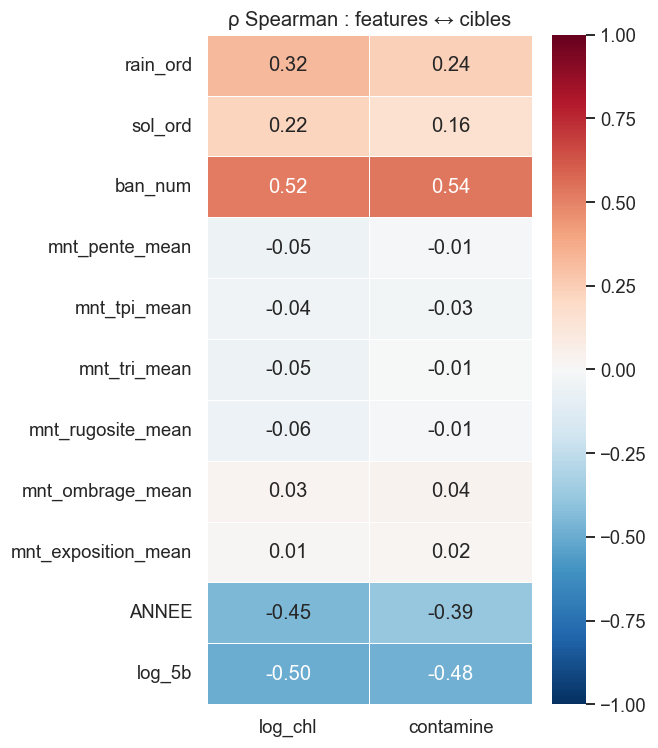

In [21]:
feature_cols = [
    'rain_ord', 'sol_ord', 'ban_num',
    'mnt_pente_mean', 'mnt_tpi_mean', 'mnt_tri_mean',
    'mnt_rugosite_mean', 'mnt_ombrage_mean', 'mnt_exposition_mean',
    'ANNEE', 'log_5b'
]
targets = ['log_chl', 'contamine']

# Calcul des ρ de Spearman pour chaque (feature, cible)
corr_ft = pd.DataFrame(index=feature_cols, columns=targets, dtype=float)
for feat in feature_cols:
    for tgt in targets:
        rho, _ = spearmanr(df[feat].fillna(-99), df[tgt])
        corr_ft.loc[feat, tgt] = rho

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(
    corr_ft.astype(float),
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax
)
ax.set_title('ρ Spearman : features ↔ cibles')
plt.tight_layout()
plt.show()

C'est la carte de navigation vers la modélisation. HISTOBANANE_HISTO_BAN domine nettement les deux colonnes l'histoire agricole des parcelles est le prédicteur le plus puissant de leur contamination actuelle. Ce résultat, obtenu sur 31 126 observations, est une preuve statistique solide du lien causal entre les pratiques bananières des décennies passées et la pollution mesurée aujourd'hui. C'est le fondement quantitatif des demandes de responsabilité.

### 5.3 Export du dataset pour la modélisation

In [23]:
cols_export = (
    feature_cols
    + targets
    + ['Taux_Chlordecone_clean', 'Taux_5b_hydro_clean',
       'COMMU_LAB', 'Sol_simple', 'RAIN', 'histoBanane_cat',
       'X', 'Y', 'ANNEE', 'ID', 'chl_censure']
)

df_model = df[cols_export].copy()
df_model.to_csv('C:/Users/Utilisateur/Downloads/chlordecone-project/data/processed//BaseCLD2026_features.csv', index=False)

print(f'✅ Dataset exporté : {df_model.shape[0]:,} lignes · {df_model.shape[1]} colonnes')
print(f'   → Cible régression  : log_chl     (médiane = {df_model["log_chl"].median():.3f})')
print(f'   → Cible classif.    : contamine   ({df_model["contamine"].mean()*100:.1f}% positifs)')
print(f'   → Fichier sauvegardé : data/processed/BaseCLD2026_features.csv')

✅ Dataset exporté : 31,126 lignes · 24 colonnes
   → Cible régression  : log_chl     (médiane = 0.003)
   → Cible classif.    : contamine   (34.6% positifs)
   → Fichier sauvegardé : data/processed/BaseCLD2026_features.csv
